# MIC / IC50 Dose-Response Analysis

Fits three-parameter logistic dose-response curves to MIC data and compares IC50 values between evolved N. glabratus populations and the ancestral strain.

Input: `Table_S2.xlsx` (one sheet per drug: FLZ, CASP, AMP-B)

## Imports and configuration

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import warnings
from pathlib import Path
from typing import Dict, List, Optional
from scipy.optimize import curve_fit
from scipy import stats

warnings.filterwarnings('ignore')

#Directories
DATA_FILE  = 'Table_S2.xlsx'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

#Excel sheet names mapped to drug names
DRUG_SHEETS = {
    'FLZ':   'fluconazole',
    'CASP':  'caspofungin',
    'AMP-B': 'amphotericin',
}

#Strain prefix used to match evolution history
EVOLUTION_CATEGORIES = {
    '40_':    'evolved_40C',
    '35_':    'evolved_35C',
    'fRS585': 'fRS585_control',
}

#Colours for plotting by evolution history
EVO_COLORS = {
    'evolved_40C':    '#D62728',
    'evolved_35C':    '#1F77B4',
    'fRS585_control': '#000000',
}
EVO_LABELS = {
    'evolved_40C':    'Evolved 40°C',
    'evolved_35C':    'Evolved 35°C',
    'fRS585_control': 'Ancestor',
}

## Load and parse data

Looks through each drug sheet for plate identifiers (`Set#_Rep#`), then extracts
strain names, drug concentrations, and OD600 values.

In [15]:
def categorize_strain(strain_name: str) -> str:
    """Map strain name to evolution history category."""
    for pattern, category in EVOLUTION_CATEGORIES.items():
        if pattern in strain_name:
            return category
    return 'unknown'

def parse_drug_sheet(sheet_name: str, drug_name: str) -> pd.DataFrame:
    df = pd.read_excel(DATA_FILE, sheet_name=sheet_name, header=None)
    records = []

    # Find all plate start positions
    plate_locs = [
        (r, c, str(df.iloc[r, c]))
        for r in range(df.shape[0])
        for c in range(df.shape[1])
        if pd.notna(df.iloc[r, c]) and re.match(r'Set\d+_Rep\d+', str(df.iloc[r, c]))
    ]

    for plate_idx, (row0, col0, plate_id) in enumerate(plate_locs):
        # Search for concentration header within the plate region
        end_row = plate_locs[plate_idx + 1][0] if plate_idx + 1 < len(plate_locs) else df.shape[0]
        region  = df.iloc[row0:end_row, col0:col0 + 20]

        conc_row_idx = None
        for i in range(region.shape[0]):
            for j in range(region.shape[1]):
                if 'Drug Concentration' in str(region.iloc[i, j]):
                    conc_row_idx = i
                    conc_col_off = j
                    break
            if conc_row_idx is not None:
                break
        if conc_row_idx is None:
            continue

        # Extract concentrations
        conc_row  = region.iloc[conc_row_idx, conc_col_off:]
        concs     = [(idx, v) for idx, v in enumerate(conc_row)
                     if pd.notna(v) and isinstance(v, (int, float)) and v >= 0]
        if not concs:
            continue

        # Extract strain rows
        for i in range(conc_row_idx + 1, region.shape[0]):
            strain = str(region.iloc[i, conc_col_off]).strip()
            if (not strain or strain == 'nan' or
                    strain == 'Blank' or 'Drug Concentration' in strain or
                    re.match(r'Set\d+_Rep\d+', strain)):
                continue
            for col_off, conc in concs:
                od = region.iloc[i, col_off]
                if pd.notna(od) and isinstance(od, (int, float)):
                    records.append({'strain': strain, 'concentration': conc,
                                    'OD': od, 'plate_id': plate_id, 'drug': drug_name})

    result = pd.DataFrame(records)
    if not result.empty:
        result['evolution_history'] = result['strain'].apply(categorize_strain)
    return result


def replace_zero_concentrations(df: pd.DataFrame) -> pd.DataFrame:
    #Replace zero concentrations with 1/10 of the lowest non-zero concentration per plate.
    for plate_id in df['plate_id'].unique():
        mask     = df['plate_id'] == plate_id
        non_zero = df.loc[mask & (df['concentration'] > 0), 'concentration']
        if len(non_zero) > 0:
            replacement = non_zero.min() / 10
            df.loc[mask & (df['concentration'] == 0), 'concentration'] = replacement
    return df

# Load all drug sheets
all_data = []
for sheet, drug in DRUG_SHEETS.items():
    drug_df = parse_drug_sheet(sheet, drug)
    if not drug_df.empty:
        all_data.append(drug_df)
        print(f'{drug}: {len(drug_df):,} records, {drug_df["strain"].nunique()} strains')

combined_data = replace_zero_concentrations(pd.concat(all_data, ignore_index=True))

fluconazole: 504 records, 37 strains
caspofungin: 504 records, 37 strains
amphotericin: 504 records, 37 strains


## Fit dose-response curves

Fits a 3-parameter logistic to each strain × drug combination:

$$OD = \frac{d}{1 + e^{b \times (\ln[C] - \ln[IC_{50}])}}$$

where *d* = maximum observed OD600, *b* = slope, *IC50* = half-maximal inhibitory concentration.
Bootstrap confidence intervals (n = 500) are calculated by resampling with replacement.

In [22]:
def logistic_4pl(concentration, d, b, ic50):
    #3-parameter logistic dose-response model
    return d / (1 + np.exp(b * (np.log(concentration) - np.log(ic50))))


def fit_strain(data: pd.DataFrame, n_bootstrap: int = 500) -> Optional[Dict]:
    #Fit dose-response curve to one strain's averaged OD data. Returns dict of fitted parameters + bootstrap IC50 CI, or None if fitting fails.
    # Average technical replicates at each concentration
    avg = data.groupby('concentration')['OD'].mean().reset_index()
    x   = avg['concentration'].values
    y   = avg['OD'].values
    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x, y  = x[valid], y[valid]
    if len(x) < 3:
        return None

    d_init   = np.max(y)
    bounds   = ([0, 0.01, np.min(x)], [2 * d_init, 50, 5 * np.max(x)])

    try:
        popt, _ = curve_fit(logistic_4pl, x, y,
                            p0=[d_init, 1.0, np.median(x)],
                            bounds=bounds, maxfev=5000)
    except Exception:
        return None

    d_fit, b_fit, ic50_fit = popt
    y_pred  = logistic_4pl(x, *popt)
    ss_res  = np.sum((y - y_pred) ** 2)
    ss_tot  = np.sum((y - y.mean()) ** 2)
    r2      = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    #Bootstrap CI for IC50
    boot_ic50 = []
    for _ in range(n_bootstrap):
        idx = np.random.choice(len(x), len(x), replace=True)
        try:
            bp, _ = curve_fit(logistic_4pl, x[idx], y[idx],
                              p0=popt, bounds=bounds, maxfev=2000)
            boot_ic50.append(bp[2])
        except Exception:
            continue

    ci_lo = np.percentile(boot_ic50, 2.5)  if boot_ic50 else np.nan
    ci_hi = np.percentile(boot_ic50, 97.5) if boot_ic50 else np.nan

    return {'d': d_fit, 'b': b_fit, 'ic50': ic50_fit,
            'ic50_ci_lo': ci_lo, 'ic50_ci_hi': ci_hi,
            'r2': r2, 'x_data': x, 'y_data': y}


#Fit all strain × drug combinations
results = []
combos  = combined_data.groupby(['strain', 'drug']).size().reset_index()[['strain', 'drug']]

for _, row in combos.iterrows():
    strain, drug = row['strain'], row['drug']
    sub = combined_data[(combined_data['strain'] == strain) &
                        (combined_data['drug']   == drug)]
    fit = fit_strain(sub)
    if fit is not None:
        evo = sub['evolution_history'].iloc[0]
        results.append({'strain': strain, 'drug': drug,
                        'evolution_history': evo, **fit})

results_df = pd.DataFrame(results)

## Export results

In [ ]:
OUT = Path('processed_outputs')
OUT.mkdir(exist_ok=True)

#IC50 results per strain
export_cols = ['strain', 'drug', 'evolution_history',
               'ic50', 'ic50_ci_lo', 'ic50_ci_hi', 'r2']
results_df[export_cols].to_csv(OUT / 'ic50_per_strain.csv', index=False)

#Wide format: one column per evolution history per drug
for drug in results_df['drug'].unique():
    sub   = results_df[results_df['drug'] == drug]
    wide  = {}
    for evo in sub['evolution_history'].unique():
        vals = sub[sub['evolution_history']==evo]['ic50'].dropna().tolist()
        wide[f'{drug}_{evo}'] = vals
    max_len = max(len(v) for v in wide.values())
    for k in wide: wide[k] += [np.nan] * (max_len - len(wide[k]))
    pd.DataFrame(wide).to_csv(OUT / f'ic50_prism_{drug}.csv', index=False)

print('Exported:')
for f in OUT.iterdir():
    print(f'  {f.name}')

## Dose-response curve figure

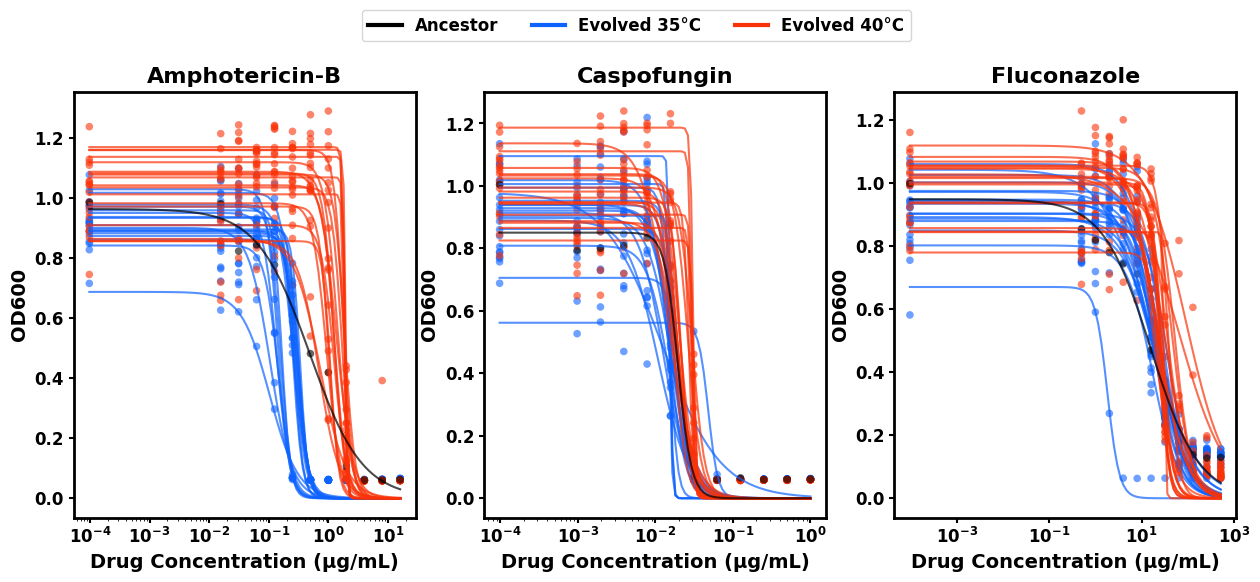

Figure saved.


In [26]:
EVO_COLORS = {
    'evolved_40C':    '#FA3208',
    'evolved_35C':    '#0E63FF',
    'fRS585_control': '#000000',
}
EVO_LABELS = {
    'evolved_40C':    'Evolved 40°C',
    'evolved_35C':    'Evolved 35°C',
    'fRS585_control': 'Ancestor',
}

drug_order  = ['amphotericin', 'caspofungin', 'fluconazole']
drug_labels = {'fluconazole':  'Fluconazole',
               'caspofungin':  'Caspofungin',
               'amphotericin': 'Amphotericin-B'}

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, drug in zip(axes, drug_order):
    drug_results = results_df[results_df['drug'] == drug]
    drug_raw     = combined_data[combined_data['drug'] == drug]

    for evo in drug_results['evolution_history'].unique():
        color       = EVO_COLORS.get(evo, '#7f7f7f')
        evo_results = drug_results[drug_results['evolution_history'] == evo]

        for _, strain_row in evo_results.iterrows():
            strain = strain_row['strain']
            raw    = drug_raw[drug_raw['strain'] == strain]
            avg    = raw.groupby('concentration')['OD'].mean().reset_index()

            ax.scatter(avg['concentration'], avg['OD'],
                       color=color, s=30, alpha=0.6, edgecolors='none')

            x_min, x_max = avg['concentration'].min(), avg['concentration'].max()
            x_smooth = np.logspace(np.log10(x_min), np.log10(x_max), 100)
            y_smooth = logistic_4pl(x_smooth,
                                    strain_row['d'],
                                    strain_row['b'],
                                    strain_row['ic50'])
            ax.plot(x_smooth, y_smooth, color=color, lw=1.5, alpha=0.7)

    ax.set_xscale('log')
    ax.set_xlabel('Drug Concentration (μg/mL)', fontsize=14, fontweight='bold')
    ax.set_ylabel('OD600', fontsize=14, fontweight='bold')
    ax.set_title(drug_labels[drug], fontsize=16, fontweight='bold')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')

# Legend
legend_handles = [
    plt.Line2D([0], [0], color=EVO_COLORS[e], lw=3, label=EVO_LABELS[e])
    for e in ['fRS585_control', 'evolved_35C', 'evolved_40C']
    if e in results_df['evolution_history'].values
]
plt.subplots_adjust(top=0.82)
legend = fig.legend(handles=legend_handles, loc='upper center',
                    bbox_to_anchor=(0.5, 0.97), ncol=3, fontsize=12, frameon=True)
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.savefig(OUTPUT_DIR / 'dose_response_curves.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.savefig(OUTPUT_DIR / 'dose_response_curves.pdf',
            bbox_inches='tight', facecolor='white')
plt.show()
print('Figure saved.')